---
title: Introduction to Neural Networks
subject: DEEP LEARNING
---

## Introduction

Deep learning models are machine learning models with multiple layers of learned representations. A **layer** refers to any transformation that maps an input to its **feature representation**. In principle, any function that can be described as a composition of layers with *differentiable operations*[^1] is called a **neural network**. Neural networks discover intricate structure in large datasets by learning good representations ({numref}`01-thought`).

[^1]: Differentiable operations allow the network to 
change its layer parameters based on prediction errors via an application of the chain rule after tracking functional dependencies.


```{figure} ./img/01-thought.png
---
name: 01-thought
width: 80%
align: center
---
**Thought as representation.** Representations are powerful. In machine translation, sentences are not translated word-for-word between two languages. Instead, a model learns a latent representation that captures the 'thought' shared by the translated sentences. 

```

The practical successes of deep learning can be attributed to three factors:

| | |
|--|--|
| **Scalability**| Deep neural networks ({numref}`01-imagenet-progress`) are created by stacking multiple layers (10-100+). Features at deep layers can be thought of as combinatorial, higher-level, and less sensitive to noise, thereby improving generalization. On the other hand, *wider layers*, i.e. layers with more parameters, memorizes features better at that level. There are tradeoffs with depth and width that has to be controlled in order to get effectively sized networks. Generally, the larger the network, the better it generalizes to test data ({numref}`01-gflops`).|
| **Large datasets** | Deep large networks ({numref}`01-imagenet-progress`) are necessary for tasks involving massive, complex, structured datasets like images and text, where the complexity of the model aligns with that of the underlying distributions in the data. Complex models allow for *automatic feature engineering*, provided that prior knowledge about the structure (or [modality](https://en.wikipedia.org/wiki/Multimodal_learning)) of the data is encoded into the network architecture. More importantly, it turns out that knowledge that neural networks learned can be re-used via **transfer learning** where are a large model pre-trained on a large dataset is adapted to specialized tasks requiring smaller datasets.|
| **Compute** | Both of the above factors require significant computational resources ({numref}`01-gflops`). GPUs are particularly well-suited for the large scale matrix operations required in deep learning with their parallel processing capabilities. |

```{figure} ./img/01-imagenet-progress.png
---
name: 01-imagenet-progress
width: 80%
align: center
---
Progress in top-5 error in the [ImageNet competition](https://en.wikipedia.org/wiki/ImageNet#ImageNet_Challenge).
```

```{figure} ./img/01-gflops.png
---
name: 01-gflops
width: 80%
align: center
---
**[Top-1 accuracy](https://stackoverflow.com/questions/37668902/evaluation-calculate-top-n-accuracy-top-1-and-top-5) vs [GFLOPs](https://en.wikipedia.org/wiki/FLOPS) on ImageNet.** Performance generally improve with increasing compute. But some architectures such as ResNet have better tradeoff than others (e.g. VGG).
```

## Fully-connected NNs

**Fully-connected networks**[^5] (FNN) consist of **linear layers** followed by an **activation**. Each layer consist of neurons that compute $\textbf{\textsf{x}}_k^{\ell + 1} = \varphi(\textbf{\textsf{x}}^{\ell} \cdot \textbf{\textsf{w}}_k^\ell + \mathsf{b}_k^\ell)$
for $k = 1, \ldots, h^\ell$ for an input $\textbf{\textsf{x}} = \textbf{\textsf{x}}^0$ where the activation $\varphi\colon \mathbb{R} \to \mathbb{R}$ is some nonlinear function. The number of neurons $h^\ell$ is called the **width** of the $\ell${sup}`th` layer. The number of layers in a network is called its **depth**. In practice, the neurons in a layer are computed in parallel using matrix operations:

$$
\underbrace{\textbf{\textsf{X}}^1}_{{B \times h}} = \varphi\left(\underbrace{\textbf{\textsf{X}}^0}_{{B \times d}}\,\underbrace{\textbf{\textsf{W}}}_{d \times h} + \underbrace{\textbf{\textsf{b}}}_{1 \times h}\right)
$$

The layer output $\textbf{\textsf{X}}^1$ is then passed as input to the next layer.

[^5]: Fully-connected networks are also known in the literature as [multilayer perceptrons](https://en.wikipedia.org/wiki/Perceptron) (MLPs).

```{figure} ./img/artificial-neuron.png
---
name: artificial-neuron
width: 80%
align: center
---
**Artificial neuron as simplistic mathematical model for the biological neuron.** Biological neurons are believed to remain inactive until the net input to the cell body (soma) reaches a certain threshold, at which point the neuron gets *activated* and fires an electro-chemical signal. [Source](https://jermwatt.github.io/machine_learning_refined/notes/13_Multilayer_perceptrons/13_2_Multi_layer_perceptrons.html) 
```

**Universal approximation.** It turns out that any continuous map $f\colon K \subset \mathbb{R}^d \to \mathbb{R}^m$ defined on a [compact set](https://en.wikipedia.org/wiki/Compact_space) $K$ can be approximated by a FNN {cite:p}`Cybenko1989`. Continuity on a compact domain are reasonable assumptions about a ground truth function that we assume exists. The following demo shows a one-dimensional curve approximated with a FNN having [ReLU activations](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)) $\varphi(z) = \max(0, z)$ for $z \in \mathbb{R}.$

In [38]:
import torch

# Ground truth
x = torch.linspace(-2 * torch.pi, 2 * torch.pi, 1000)
y = torch.sin(x) + 0.3 * x

# Get sorted sample. Shifted for demo
B = sorted(torch.randint(30, 970, size=(24,)))
xs = x[B,]
ys = y[B,]

# ReLU approximation
z = torch.zeros(1000,) + ys[0]
for i in range(len(xs) - 1):
    if torch.isclose(xs[i + 1], xs[i]):
        m = torch.tensor(0.0)
    else:
        M = (ys[i+1] - ys[i]) / (xs[i+1] - xs[i])
        s, m = torch.sign(M), torch.abs(M)
    z += s * (torch.relu(m * (x - xs[i])) - torch.relu(m * (x - xs[i+1])))

**NOTE:** This only works for target $f$ with compact domain $[a, b]$ consistent with the theorem.

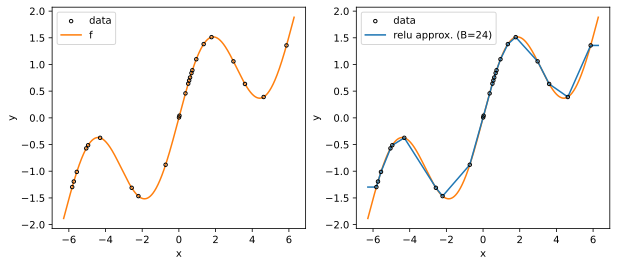

In [39]:
import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline
backend_inline.set_matplotlib_formats("svg")

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(xs, ys, facecolor="none", s=12, edgecolor="k", zorder=3, label="data")
ax[0].plot(x, y, color="C1", label="f")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].legend();

ax[1].scatter(xs, ys, facecolor="none", s=12, edgecolor="k", zorder=4, label="data")
ax[1].plot(x, z, color="C0", label=f"relu approx. (B={len(B)})", zorder=3)
ax[1].plot(x, y, color="C1")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[1].legend()

plt.savefig("plots/0-relu_approx.svg", dpi=300, bbox_inches="tight");

:::{figure} ./plots/0-relu_approx.svg
---
name: plots/0-relu_approx
align: center
---
**Approximating a sinusoidal function using ReLU neurons.** The algorithm works by constructing step-like functions `__/‾‾` and `‾‾\__`  but with slope $\nu$ between adjacent points by canceling out two ReLU curves with slopes +$\nu$ and -$\nu$. These step functions increment each other starting with `ys[0]` and ends with `ys[-1]`. This is an example of universal approximation done by means of increasing layer width.
:::

## Linear Classification  

Neural networks classify data by learning separating hyperplanes, obtained through a sequence of transformations on the input[^2]. The class scores (called **logits**) are proportional to the distance of a data point from each hyperplane. The scores can be converted to a probability distribution over the class labels by applying a positive increasing function $f\colon \mathbb{R} \to \mathbb{R}^+$ to the logits, converting it into a probability vector:

$$
\textsf{p}_j = \frac{f(\textsf{s}_j)}{\sum_k f(\textsf{s}_k)}.
$$


[^2]: The intermediate outputs of these transformations are called representations.  

A natural choice for $ f $ is the exponential function $\exp$ which maps $ \mathbb{R} $ to $ \mathbb{R}^+ $ 1-1, s.t. $ \exp(-\infty) = 0 $ and $ \exp (+\infty) = +\infty.$ Hence, $\textbf{\textsf{s}} = [-\infty, 1, H]$ becomes vector $\textbf{\textsf{p}} = [0, \epsilon, 1 - \epsilon]$ where $H \gg 1.$ This leads to the **softmax function**[^3]:  

$$
\text{Softmax}(\textbf{\textsf{s}})_j = \frac{\exp(\textsf{s}_j - \textsf{s}^*)}{\sum_k \exp(\textsf{s}_k - \textsf{s}^*)}, \quad \text{where} \;\; \textsf{s}^* = \max_j \textsf{s}_j.
$$

This formulation ensures numerical stability by subtracting the largest logit $ \textsf{s}^* $, so that the denominator is at least 1.  

**Example: Logistic Regression.** For binary classification, only one probability needs to be computed, since $ p_0 + p_1 = 1 $. In this case, softmax simplifies to the **sigmoid function**:  

$$
p_1 = \frac{1}{1 + \exp(-(\textsf{s}_1 - \textsf{s}_0))}
$$

where $ p_1 $ represents the probability of the positive class. Notice that logistic regression can be seen as a single-layer neural network, where the logits are computed as $ \textsf{s}_k = \textbf{\textsf{w}}_k \cdot \textbf{\textsf{x}} + b_k $. This allows us to rewrite the difference of logits as:  

$$
\textsf{s}_1 - \textsf{s}_0 = (\textbf{\textsf{w}}_1 - \textbf{\textsf{w}}_0) \cdot \textbf{\textsf{x}} + (b_1 - b_0),
$$

which corresponds to a single separating hyperplane.  

[^3]: A more precise name might be soft-*arg*max, as exponentiation amplifies the effect of the largest logit.  

In [ ]:
import numpy as np

s = np.linspace(-10, 10, 300)
p = 1 / (1 + np.exp(-s))

p_inv = lambda p: np.log(p / (1 - p))
threshold = 0.15
s_lo = p_inv(threshold)
s_hi = p_inv(1 - threshold)

# scores of positive and negative samples
s0 = [-8.0, -7.8, -6.5, -5.0, -2.5, -1.25, 0.3, -7.6]   # y = 0
s1 = [-2.2,  0.0,  6.0,  1.3,  5.0,   7.5, 7.6,  8.3]   # y = 1

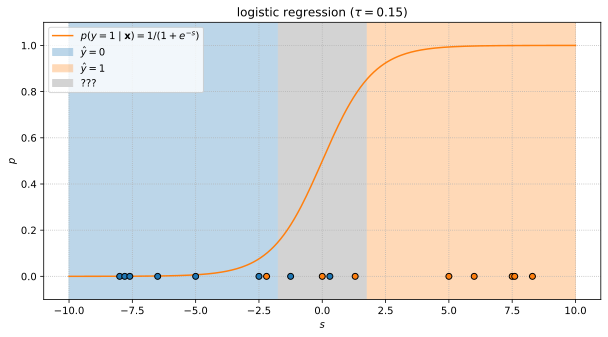

In [10]:
plt.figure(figsize=(10, 5))
plt.title(r"logistic regression ($\tau = 0.15$)")
plt.plot(s, p, label=r"$p(y=1 \mid {\mathbf{x}}) = 1 / (1 + e^{-s})$", color="C1")
for i in range(len(s0)):
    plt.scatter(s0[i], 0.0, color="C0", zorder=3, edgecolor="k")
    plt.scatter(s1[i], 0.0, color="C1", zorder=3, edgecolor="k")

plt.axvspan(-10.0, s_lo, -2.0, 2.0, color="C0", label=r"$\hat{y} = 0$", alpha=0.3)
plt.axvspan( s_hi, 10.0, -2.0, 2.0, color="C1", label=r"$\hat{y} = 1$", alpha=0.3)
plt.axvspan( s_lo, s_hi, -2.0, 2.0, color="lightgray", label="???")
plt.xlabel("$s$")
plt.ylabel("$p$")
plt.legend()
plt.ylim(-0.1, 1.1)
plt.grid(linestyle="dotted");

plt.savefig("plots/1-logistic-regression.svg", dpi=300, bbox_inches="tight");

:::{figure} plots/1-logistic-regression.svg
---
label: plots/1-logistic-regression
---
**Logistic regression assigns a probability based on the sigmoid function.**
Note that the sigmoid assigns ${p} =\frac{1}{2}$ at the hyperplane where ${s} = 0.$ It scales symmetrically with respect to the distance of the data points from the decision boundary. This is nice, otherwise the prediction will not be invariant with respect to relabeling. Note that this example shows a model with well-calibrated scores.
:::


For the general case of multiclass classification, we have class scores $\textsf{s}_k = \textbf{\textsf{w}}_k \cdot \textbf{\textsf{x}} + \textsf{b}_k$ with the softmax acting like a **voting function**. The weight vector $\textbf{\textsf{w}}_k$ can be interpreted as a learned pattern, so that the projection $\textbf{\textsf{x}} \cdot \textbf{\textsf{w}}_k$ corresponds to a scaled similarity. This degree of similarity is then modulated by the activation, with the bias $\textsf{b}_k$ shifting the activation threshold.

In [11]:
# grid of points
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

# parameters
w = [1, 1]
b = 0

def sigmoid_neuron(x, y):
    z = w[0] * x + w[1] * y + b
    return 1 / (1 + np.exp(-z))

def relu_neuron(x, y):
    z = w[0] * x + w[1] * y + b
    return np.maximum(0, z)

The sigmoid unit assigns a gradient along the normal of the hyperplane defined by $\textbf{\textsf{w}}$ and $b$ in the input space $\mathbb{R}^2$. This effectively reduces the input
space to one dimension along the direction of ${\textbf{\textsf{w}}} = [1, 1].$ Here $H$ is the linear decision boundary defined by points $\textbf{\textsf{x}}$ such that $\textbf{\textsf{x}} \cdot \textbf{\textsf{w}} + b = 0.$ ReLU unit has sharp cutoff at zero ({numref}`2-sigmoid-relu`).

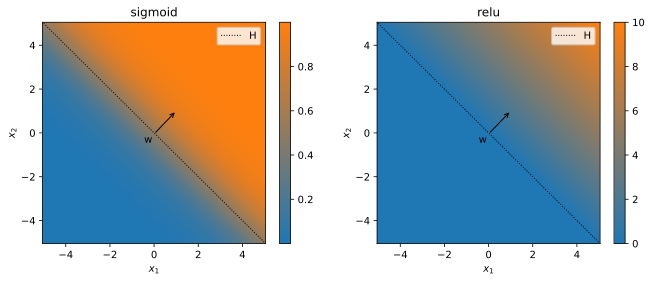

In [21]:
from matplotlib.colors import LinearSegmentedColormap

colors = ["C0", "C1"]
n_bins = 100
cm = LinearSegmentedColormap.from_list(name="", colors=colors, N=n_bins)

def plot_grid(ax, X, Y, Z, title=""):
    p1 = (-0.45, -0.45)
    p2 = (1, 1)
    ax.annotate(r'$\mathsf{w}$', xy=p2, xytext=p1, arrowprops=dict(arrowstyle='->'))
    ax.plot(x, -x, color='k', linewidth=1, linestyle='dotted', label='H')

    im = ax.pcolormesh(X, Y, Z, shading='auto', cmap=cm, rasterized=True)
    cbar = plt.colorbar(im, ax=ax)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(title, size=12)
    ax.legend()


fig, ax = plt.subplots(1, 2, figsize=(11, 4))
Z0 = sigmoid_neuron(X, Y)
Z1 = relu_neuron(X, Y)
plot_grid(ax[0], X, Y, Z0, title="sigmoid")
plot_grid(ax[1], X, Y, Z1, title="relu")
plt.savefig("plots/2-sigmoid-relu.svg", dpi=300, bbox_inches="tight");

:::{figure} plots/2-sigmoid-relu.svg
---
label: 2-sigmoid-relu
---
Activation color map given a weight vector $\textbf{\textsf{w}}$ and zero bias. 
:::

---